# TP9 : Analyse de données - Évaluation

## Introduction

La supraconductivité est un phénomène physique où certains matériaux perdent toute résistance électrique en dessous d'une température critique. Ce phénomène a de nombreuses applications (IRM médicales, accélérateurs de particules, trains à lévitation magnétique), mais la plupart des supraconducteurs ne fonctionnent qu'à des températures extrêmement basses, ce qui limite leur utilisation pratique.

L'enjeu scientifique est donc de découvrir des matériaux supraconducteurs à température critique élevée. Pour cela, il faut comprendre comment les propriétés physico-chimiques d'un matériau influencent sa température critique.

### Les données

Le dataset contient 10,000 supraconducteurs décrits par :
- **81 features** : propriétés physico-chimiques incluant la composition atomique (nombre d'atomes de chaque élément), les propriétés atomiques moyennes (masse, rayon, électronégativité, valence, etc.), et des descripteurs structurels
- **1 target** : la température critique de supraconductivité (en Kelvin), variant de 0K à 185K

**Objectif du TP** : Explorer ces données pour comprendre visuellement et quantitativement comment les features expliquent la température critique.

---

**Bibliothèques autorisées** : Vous devez utiliser uniquement les bibliothèques listées ci-dessous. Aucune autre bibliothèque n'est autorisée pour ce TP.

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import Isomap
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

---

## Exercice 1 : Exploration des données

Chargez les données et réalisez une analyse descriptive et exploratoire. Identifiez au moins deux caractéristiques dans ces données qui pourraient influencervotre analyse par la suite.

**Barème** : /3

la forme de la table de données est (5000, 83)

le nombre de valeurs null  dans ma table de données est de 0
les deux classes de données plus fréquentes dans ma table sont [0.0, 2.0]

 la moyenne de nos features est de 540.92724609375

les différentes caractéristiques des features sont :
               0            1            2            3            4   \
count  5000.00000  5000.000000  5000.000000  5000.000000  5000.000000   
mean      4.11500    87.608772    72.905327    71.280922    58.355526   
std       1.43422    29.450884    33.164368    30.824778    36.315910   
min       1.00000     6.941000     6.941000     5.685033     3.193745   
25%       3.00000    72.795532    52.158150    58.298268    35.279766   
50%       4.00000    84.615479    60.526478    66.342896    39.971191   
75%       5.00000   100.861275    86.150291    78.378532    72.963463   
max       9.00000   208.980392   208.980392   208.980392   208.980392   

                5            6            7          

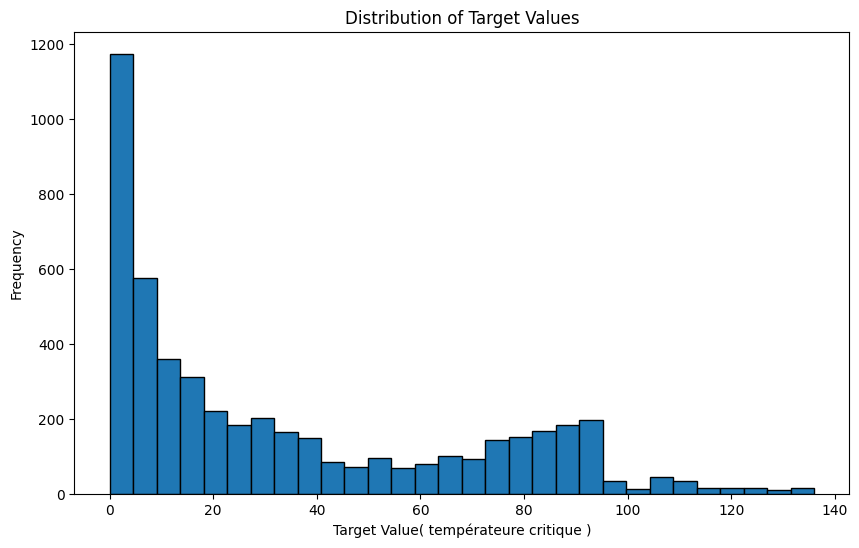

In [42]:
# on charge le fichier de données
data=pd.read_csv('superconductivity_data.csv')

# on cconverit les données en unbe table nympy de type folat32
X=data.to_numpy('float32')

# on affiche la forme de la table de données
print(f"la forme de la table de données est {X.shape}")
# on affiche le nombre de valeurs null  dans la table de données
print(f"\nle nombre de valeurs null  dans ma table de données est de {np.isnan(X).sum()}")

# on affiche les deux classes de données plus fréquentes dans la table
print(f"les deux classes de données plus fréquentes dans ma table sont {pd.Series(X.flatten()).value_counts().index[:2].tolist()}")

# on verra maintenant les differents features de la table,leurs max,min,mean,std.....
X_features=X[:,:81]
print(f"\n la moyenne de nos features est de {X_features.mean()}")
print(f"\nles différentes caractéristiques des features sont :\n{pd.DataFrame(X_features).describe()}")

# on sépare le target de nos données
target=X[:,81:82]
# la moyenne de notre target
print(f"\nla moyenne de notre target est de {target.mean()}")


# on essaye de réduire la dimensionnalité des donnés à 2 pour pouvoir en tirer quelques caractéristiques
pca_model=PCA(2)
X_pca=pca_model.fit_transform(X_features)

# on affiche la variance expliquée par les deux composantes principales
print(f"\nla variance expliquée par les deux composantes principales est de {pca_model.explained_variance_ratio_.sum()}")



plt.figure(figsize=(10,6))
plt.hist(target, bins=30, edgecolor='k')
plt.title('Distribution of Target Values')
plt.xlabel('Target Value( températeure critique )')
plt.ylabel('Frequency')
plt.show()


1)On remarque à partir de l'histogramme que la distribution de nos données n'est pas uniforme, avec une majorité des supraconducteurs qui ont une température critique entre 0 et 20 K. le modèle risque de mieux prédire les températures critiques basses bien meilleurs que celle hautes car il serait entrainé d'avantage sur des températures basses!

2)ON remarque aussi la grande différence entre les features, donc avant toute réduction de dimnesionalité, on procède d'abord à centrer et à réduire nos features.

---

## Exercice 2 : Visualisation

Créez une visualisation 2D (nuage de points) qui représente au mieux les différences de température critique entre les supraconducteurs. Testez plusieurs approches et identifiez la meilleure.

**Barème** : /6


la variance expliquée par les deux composantes principales après normalisation est de 0.49395501613616943


c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 5 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr

Text(0.5, 1.0, 'Isomap — Projection 2D des supraconducteurs (Centrés et réduits)')

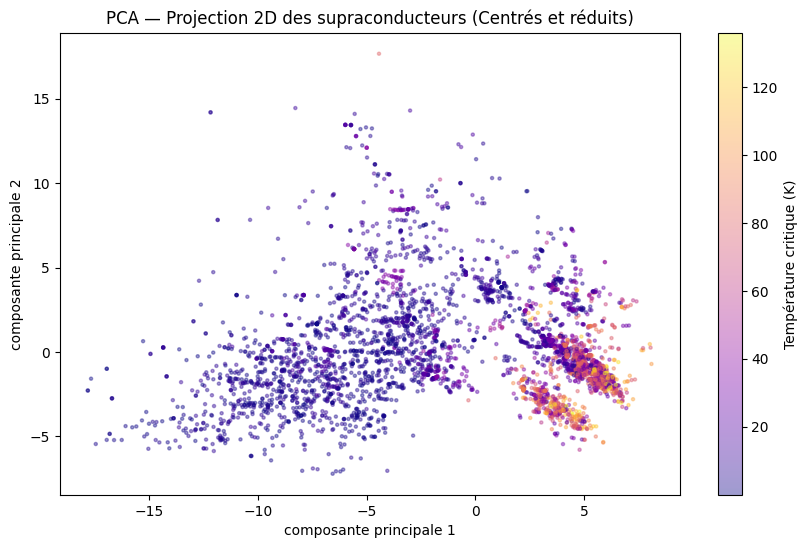

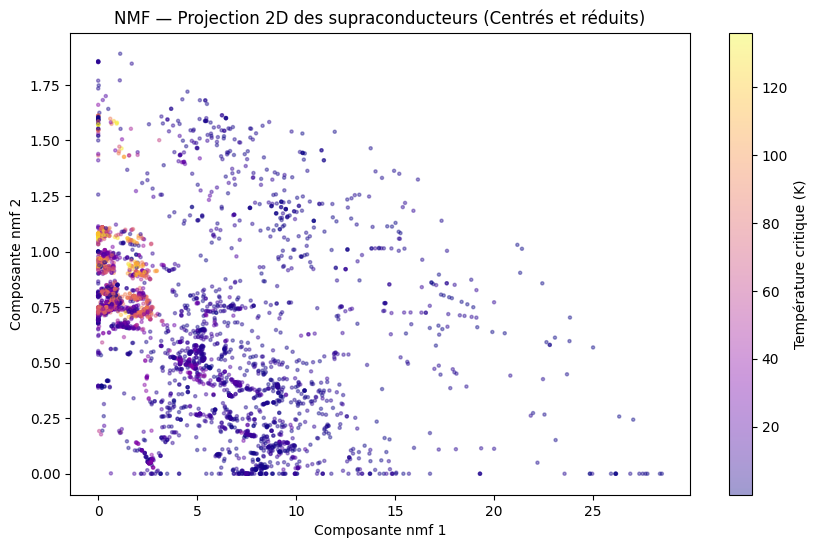

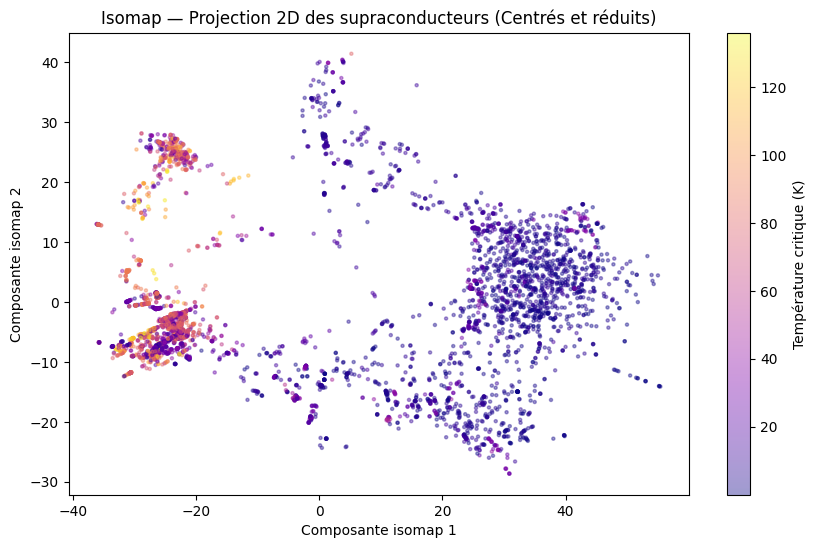

In [ ]:
# on a remarqué que les données des features sont très dispersées, on est censé les normaliser puis effectuer la réduction de dimensionnalité

# première approche de l'exo2 :Pca

# normalisation et standardisation des données
X_normalized_f=(X_features - X_features.mean(axis=0)) / X_features.std(axis=0)
# on applique la pca sur les données normalisées
pca_model_f=PCA(2)
X_pca_f=pca_model_f.fit_transform(X_normalized_f)
# on affiche la variance expliquée par les deux composantes principales après normalisation
print(f"\nla variance expliquée par les deux composantes principales après normalisation est de {pca_model_f.explained_variance_ratio_.sum()}")
# on affiche la projection 2d de notre PCA APRÈS normalisation
plt.figure(figsize=(10,6))
plt.scatter(X_pca_f[:, 0], X_pca_f[:, 1],c=target.flatten(), cmap='plasma', alpha=0.4, s=5)
plt.colorbar(label='Température critique (K)')
#titre des axes et du graphique
plt.xlabel('composante principale 1')
plt.ylabel('composante principale 2')
plt.title('PCA — Projection 2D des supraconducteurs (Centrés et réduits)')


# deuxieme approche de l'exo2 : NMF

# comme on a déja normalisé les données, on applique directement le Nmf 
# c'etait pas une bonne idée car le NMF ne gère pas les données négatives, on utlise directement les données bruts
nmf_model=NMF(2)
X_nmf=nmf_model.fit_transform(X_features)

# on pourra afficher maintenant la projection 2d de notre NMF
plt.figure(figsize=(10,6))
plt.scatter(X_nmf[:, 0], X_nmf[:, 1],c=target.flatten(), cmap='plasma', alpha=0.4, s=5)
plt.colorbar(label='Température critique (K)')
#titre des axes et du graphique
plt.xlabel('Composante nmf 1')
plt.ylabel('Composante nmf 2')
plt.title('NMF — Projection 2D des supraconducteurs (Centrés et réduits)')


# troisième approche de l'exo2 : Isomap
isomap_model=Isomap(n_neighbors=10, n_components=2)
X_isomap=isomap_model.fit_transform(X_normalized_f)

# on affiche la projection 2d de notre Isomap
plt.figure(figsize=(10,6))
plt.scatter(X_isomap[:, 0], X_isomap[:, 1],c=target.flatten(), cmap='plasma', alpha=0.4, s=5)
plt.colorbar(label='Température critique (K)')
#titre des axes et du graphique
plt.xlabel('Composante isomap 1')
plt.ylabel('Composante isomap 2')
plt.title('Isomap — Projection 2D des supraconducteurs (Centrés et réduits)')

Selon moi, la meilleure approche pour représenter les différences de températures critiques est l’Isomap, car avec l’Isomap, les points chauds forment un cluster distinct à gauche et les points avec une température basse forment un autre à droite. Contrairement aux deux autres approches, on n’arrive pas à distinguer nettement les points et leurs degrés de température, car ils se superposent.

---

## Exercice 3 : Modélisation prédictive

Construisez un modèle de régression capable de prédire la température critique à partir des 81 features. Testez plusieurs approches et identifiez le meilleur modèle.

**Barème** : /6

In [53]:
# on va d'abord 
n=len(X_features)
size=int(n*0.8)

# comme vu au tp8, pour garantirque le meme échantillon de data est génére à chaque fois.
np.random.seed(42)
# permutation aléatoire des indices
indices=np.random.permutation(n)
# on distingue les indices de test et ceux de train 5D2JA Fait au tp8
train_indices=indices[:size]
test_indices=indices[size:]

# pour faciliter le travail de test de plusieurs apporches je cree une fonction
# qui prend comme parametre le model,les X-train , X_test , target_train,target_test

def tester_model(model,X_train,X_test,Y_train,Y_test):
    # model déja initialisé avant l'appel
    # on le traine direcetment sur X_train et Y_train
    model.fit(X_train,Y_train)
    
    # model trainé? ON PRédit alors les valeurs de Y_test
    Y_prediction=model.predict(X_test)
    
    # on calcule les statistiques de notre model
    # erreur quadaratique mse, r2 score ..
    mse=np.mean((Y_test - Y_prediction)**2) # -> mse
    
    r2_score=1 - (np.sum((Y_test - Y_prediction)**2) / np.sum((Y_test - np.mean(Y_test))**2)) # R2 SCORE
    
    # on affiche les résultats
    
    print(f"mse : {mse}")
    print(f"R2 score : {r2_score}")
    print( "--"*10)
    print("\n")

model_reg=LinearRegression()
print("Résultats du modèle de régression linéaire :")
tester_model(model_reg,X_normalized_f[train_indices],X_normalized_f[test_indices],target[train_indices],target[test_indices])

alpha_ridges=[1,10,100,1000]

for alpha in alpha_ridges:
    model_ridge=Ridge(alpha)
    print(f"Résultats du modèle de Ridge Regression avec alpha={alpha} :")
    tester_model(model_ridge,X_normalized_f[train_indices],X_normalized_f[test_indices],target[train_indices],target[test_indices])


Résultats du modèle de régression linéaire :
mse : 327.431884765625
R2 score : 0.721411943435669
--------------------


Résultats du modèle de Ridge Regression avec alpha=1 :
mse : 2050.80908203125
R2 score : -1743.884521484375
--------------------


Résultats du modèle de Ridge Regression avec alpha=10 :
mse : 2026.787841796875
R2 score : -1723.4466552734375
--------------------


Résultats du modèle de Ridge Regression avec alpha=100 :
mse : 1975.51953125
R2 score : -1679.826171875
--------------------


Résultats du modèle de Ridge Regression avec alpha=1000 :
mse : 1882.2373046875
R2 score : -1600.4591064453125
--------------------




Le modèle avec les meilleurs résultats est celui de la régression linéaire, avec un MSE nettement plus faible que les modèles de Ridge et un R² beaucoup plus proche de 1 (cela est valable pour les deux jeux de données testés : X_features et X_normalized_f).
On conclut qu'il n'y a pas de problème de surapprentissage dans notre modèle, car il dispose de suffisamment de données (10 000 échantillons) pour apprendre sans surapprentissage

---

## Critères d'évaluation généraux

Votre travail sera évalué sur :

**Rigueur méthodologique** :
- Justification de tous vos choix (méthodes, paramètres, prétraitements)
- Méthodologie d'évaluation appropriée (séparation train/test, validation, métriques)
- Documentation claire de votre démarche

**Exploration et créativité** :
- Variété des approches testées (vous devez tester plusieurs méthodes/paramètres/prétraitements)
- Capacité à proposer et justifier vos propres critères d'évaluation
- Esprit critique sur les résultats obtenus

**Communication** :
- Code clair, commenté et bien organisé
- Tableaux comparatifs de vos différentes approches
- Synthèses concises expliquant vos conclusions

**Important** : Une approche rigoureuse et bien documentée vaut mieux qu'une approche complexe mal justifiée. Expliquez vos choix, comparez vos résultats, et soyez critiques.

**Attention** : L'utilisation de chatbots type ChatGPT est complètement interdite et sera fortement sanctionnée. J'ai été assez clément jusqu'ici mais je vous assure que cela se voit facilement lorsque vous copiez-collez du code ou du texte dans vos TP.

**Barème** : /5